# 04. Eksperimen Transfer Learning (ResNet18) - PneumoVision_AI

## 1. Pendahuluan & Latar Belakang Eksperimen

Selamat datang di tahap keempat pengembangan **PneumoVision_AI**! 🫁

### Apa itu Transfer Learning?
**Transfer Learning** adalah teknik dalam deep learning di mana model yang telah dilatih pada dataset raksasa (seperti ImageNet dengan lebih dari 1,2 juta citra dan 1.000 kategori) digunakan kembali untuk menyelesaikan tugas baru pada dataset target yang lebih spesifik.

Alih-alih melatih jutaan bobot konvolusi dari nilai acak (*from scratch*), model memanfaatkan representasi fitur visual hierarkis yang sudah sangat matang—mulai dari deteksi garis, sudut, kontras, hingga tekstur kompleks yang dipelajari dari ImageNet—lalu menyesuaikan bobot tersebut (*fine-tuning*) untuk mengenali opasitas dan infiltrat pneumonia pada citra rontgen dada.

### Mengapa ResNet18 Dipilih sebagai Eksperimen Pertama?
1. **Residual Connections (Skip Connections)**: Arsitektur ResNet mengatasi masalah *vanishing gradient* pada jaringan dalam, memungkinkan konvergensi yang stabil dan cepat.
2. **Ukuran yang Ringkas & Efisien**: ResNet18 adalah varian terkecil dari keluarga ResNet (~11,17 juta parameter). Model ini menawarkan trade-off ideal antara kapasitas representasi fitur yang kaya dan efisiensi komputasi, sehingga sangat layak dijalankan pada CPU/GPU terbatas.
3. **Tolok Ukur Standar Industri**: ResNet18 merupakan standar *de facto* dalam literatur computer vision untuk membandingkan model dasar sebelum beralih ke varian yang lebih berat seperti DenseNet atau EfficientNet.

### Perbandingan dengan Baseline CNN:
Pada notebook sebelumnya (`03_Baseline_Model.ipynb`), model Baseline CNN sederhana dari nol berhasil mencapai **Recall Pneumonia 98,72%** pada test set, namun memiliki **Specificity Normal yang rendah (38,89%)** dan akurasi test set sebesar **76,28%** akibat keterbatasan kedalaman ekstraksi fitur.

Eksperimen ini bertujuan menguji secara objektif:
> *"Apakah pretrained ResNet18 mampu meningkatkan kemampuan generalisasi, memperbaiki Specificity pada kelas Normal, dan mempertahankan Recall tinggi pada kelas Pneumonia secara adil di bawah kondisi data yang sama?"*

> ⚠️ **Disclaimer Medis**:  
> *PneumoVision_AI adalah prototipe penapisan (*screening/research prototype*) untuk tujuan riset dan edukasi, serta **BUKAN** merupakan alat diagnosis medis klinis (*clinical diagnostic tool*).*

## 2. Setup & Persiapan Data Loader

Kita mengimpor pustaka yang diperlukan, menetapkan random seed (42) agar eksperimen bersifat *reproducible*, dan menyiapkan data loader dari pipeline preprocessing yang identik dengan notebook 02 dan 03.

### Kompatibilitas Preprocessing untuk Pretrained ResNet18:
- Citra di-resize ke `(224, 224)` (ukuran input standar keluarga ResNet).
- Citra dipastikan memiliki 3 kanal (RGB) via `img.convert('RGB')`.
- Diterapkan normalisasi standar ImageNet: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]` yang persis sama dengan distribusi data pelatihan bobot pretrained ResNet18.

In [1]:
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set seed untuk konsistensi eksperimen
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style="whitegrid", font_scale=1.05)

print(f"Perangkat komputasi aktif : {device}")
print(f"Random seed ditetapkan    : {RANDOM_SEED}")

Perangkat komputasi aktif : cpu
Random seed ditetapkan    : 42


In [2]:
# Path dataset relatif yang aman
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

# Kumpulkan file train asli
train_normal = sorted([p for p in (data_dir / 'train' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
train_pneu = sorted([p for p in (data_dir / 'train' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

raw_train_paths = train_normal + train_pneu
raw_train_labels = [0] * len(train_normal) + [1] * len(train_pneu)

# Kumpulkan file test asli (dikunci murni untuk evaluasi final)
test_normal = sorted([p for p in (data_dir / 'test' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
test_pneu = sorted([p for p in (data_dir / 'test' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

test_paths = test_normal + test_pneu
test_labels = [0] * len(test_normal) + [1] * len(test_pneu)

# Stratified train-val split 80:20 (identik dengan notebook 02 & 03)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=raw_train_labels
)

class ChestXRayDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        with Image.open(path) as img:
            img_rgb = img.convert('RGB')
        if self.transform:
            image_tensor = self.transform(img_rgb)
        else:
            image_tensor = transforms.ToTensor()(img_rgb)
        return image_tensor, torch.tensor(label, dtype=torch.long)

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = ChestXRayDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform=val_test_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data Loader siap untuk ResNet18:")
print(f"- Train : {len(train_dataset)} sampel ({len(train_loader)} batch)")
print(f"- Val   : {len(val_dataset)} sampel ({len(val_loader)} batch)")
print(f"- Test  : {len(test_dataset)} sampel ({len(test_loader)} batch, terkunci)")

Data Loader siap untuk ResNet18:
- Train : 4172 sampel (66 batch)
- Val   : 1044 sampel (17 batch)
- Test  : 624 sampel (10 batch, terkunci)


## 3. Membangun Model Pretrained ResNet18

Langkah-langkah pembuatan model:
1. Memuat model **ResNet18** lengkap dengan bobot pretrained ImageNet (`weights=models.ResNet18_Weights.DEFAULT`).
2. Mempertahankan arsitektur backbone convolutional ResNet18.
3. Mengganti layer *Fully-Connected* terakhir (`model.fc`) dari 1.000 kelas ImageNet menjadi **2 kelas** (`NORMAL` dan `PNEUMONIA`).

In [3]:
# Muat pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Ganti output fully-connected layer menjadi 2 kelas
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Arsitektur ResNet18 Pretrained ===")
print(f"Input Features fc layer : {num_features}")
print(f"Output Classes fc layer: {model.fc.out_features}")
print(f"Total Parameter        : {total_params:,}")
print(f"Trainable Parameter    : {trainable_params:,}")
print("-" * 50)
print(f"Classifier Head:\n{model.fc}")

=== Arsitektur ResNet18 Pretrained ===
Input Features fc layer : 512
Output Classes fc layer: 2
Total Parameter        : 11,177,538
Trainable Parameter    : 11,177,538
--------------------------------------------------
Classifier Head:
Linear(in_features=512, out_features=2, bias=True)


## 4. Konfigurasi Training & Eksperimen

Agar perbandingan dengan model baseline bersifat **adil (*fair comparison*)**:
- **Fungsi Loss**: `nn.CrossEntropyLoss` menggunakan **Class Weights yang persis sama** dengan notebook 03:
  $$\text{Weight}_{NORMAL} = 1.9441, \quad \text{Weight}_{PNEUMONIA} = 0.6731$$
- **Optimizer**: `Adam` dengan **Initial Learning Rate: 1e-4** (nilai yang lebih kecil dari baseline 1e-3 untuk mencegah hilangnya fitur berharga dari pretrained weights).
- **Durasi Pelatihan**: Maksimal 10 Epoch dengan pemantauan validasi dan penyimpanan model terbaik berdasarkan **Validation F1-Score (Macro)**.
- **Early Stopping**: Diterapkan toleransi *patience = 3 epoch* jika performa validasi tidak membaik untuk mencegah overfitting.

In [4]:
# Bobot kelas identik dengan baseline untuk fair comparison
class_weights = torch.tensor([1.9441, 0.6731], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

LEARNING_RATE = 1e-4
EPOCHS = 10
PATIENCE = 3

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Direktori penyimpanan checkpoint
checkpoint_dir = Path('../models/checkpoints') if Path('../models/checkpoints').exists() else Path('models/checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / 'resnet18_transfer_best.pth'

print("Konfigurasi Eksperimen Transfer Learning ResNet18:")
print(f"- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])")
print(f"- Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"- Max Epochs    : {EPOCHS} (Early Stopping Patience={PATIENCE})")
print(f"- Checkpoint    : {best_checkpoint_path}")

Konfigurasi Eksperimen Transfer Learning ResNet18:
- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])
- Optimizer     : Adam (lr=0.0001)
- Max Epochs    : 10 (Early Stopping Patience=3)
- Checkpoint    : ..\models\checkpoints\resnet18_transfer_best.pth


## 5. Loop Pelatihan & Monitoring Validasi

Setiap epoch mencatat 7 metrik utama:
1. `Train Loss`
2. `Validation Loss`
3. `Train Accuracy`
4. `Validation Accuracy`
5. `Validation Precision Macro`
6. `Validation Recall Macro`
7. `Validation F1 Macro`

In [5]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_prec': [],
    'val_rec': [],
    'val_f1': []
}

best_val_f1 = 0.0
patience_counter = 0
start_time = time.time()

print("Memulai pelatihan ResNet18 Transfer Learning...\n" + "=" * 75)

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    
    # --- Fase Training ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == targets).sum().item()
        train_total += targets.size(0)
        
    ep_train_loss = running_train_loss / train_total
    ep_train_acc = train_correct / train_total
    
    # --- Fase Validasi ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)
            
            val_preds_all.extend(preds.cpu().numpy())
            val_targets_all.extend(targets.cpu().numpy())
            
    ep_val_loss = running_val_loss / val_total
    ep_val_acc = val_correct / val_total
    ep_val_prec = precision_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_rec = recall_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_f1 = f1_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    
    # Catat history
    history['train_loss'].append(ep_train_loss)
    history['train_acc'].append(ep_train_acc)
    history['val_loss'].append(ep_val_loss)
    history['val_acc'].append(ep_val_acc)
    history['val_prec'].append(ep_val_prec)
    history['val_rec'].append(ep_val_rec)
    history['val_f1'].append(ep_val_f1)
    
    ep_time = time.time() - t_start
    
    # Evaluasi checkpoint terbaik
    if ep_val_f1 > best_val_f1:
        best_val_f1 = ep_val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': ep_val_loss,
            'val_acc': ep_val_acc,
            'val_prec': ep_val_prec,
            'val_rec': ep_val_rec,
            'val_f1': ep_val_f1,
            'architecture': 'resnet18_pretrained'
        }, best_checkpoint_path)
        best_mark = "⭐ (Best Model Disimpan)"
    else:
        patience_counter += 1
        best_mark = f"(Patience: {patience_counter}/{PATIENCE})"
        
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ({ep_time:.1f}s) | "
          f"Train Loss: {ep_train_loss:.4f}, Acc: {ep_train_acc*100:.2f}% | "
          f"Val Loss: {ep_val_loss:.4f}, Acc: {ep_val_acc*100:.2f}%, F1: {ep_val_f1:.4f} {best_mark}")
          
    # Cek Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Performa validasi tidak membaik selama {PATIENCE} epoch berturut-turut. Pelatihan dihentikan.")
        break

total_time = time.time() - start_time
print("=" * 75)
print(f"Pelatihan selesai dalam: {total_time/60:.2f} menit")
print(f"Model terbaik disimpan di: {best_checkpoint_path} (Best Val F1: {best_val_f1:.4f})")

Memulai pelatihan ResNet18 Transfer Learning...


Epoch [01/10] (390.4s) | Train Loss: 0.1318, Acc: 95.21% | Val Loss: 0.2303, Acc: 89.08%, F1: 0.8725 ⭐ (Best Model Disimpan)


Epoch [02/10] (376.3s) | Train Loss: 0.0667, Acc: 97.60% | Val Loss: 0.0578, Acc: 98.08%, F1: 0.9751 ⭐ (Best Model Disimpan)


Epoch [03/10] (407.9s) | Train Loss: 0.0421, Acc: 98.37% | Val Loss: 0.0572, Acc: 97.51%, F1: 0.9682 (Patience: 1/3)


Epoch [04/10] (352.1s) | Train Loss: 0.0490, Acc: 98.44% | Val Loss: 0.0614, Acc: 97.61%, F1: 0.9693 (Patience: 2/3)


Epoch [05/10] (525.3s) | Train Loss: 0.0321, Acc: 98.75% | Val Loss: 0.0983, Acc: 95.59%, F1: 0.9451 (Patience: 3/3)

[Early Stopping] Performa validasi tidak membaik selama 3 epoch berturut-turut. Pelatihan dihentikan.
Pelatihan selesai dalam: 34.21 menit
Model terbaik disimpan di: ..\models\checkpoints\resnet18_transfer_best.pth (Best Val F1: 0.9751)


## 6. Kurva Belajar (Learning Curves)

Kita memvisualisasikan perbandingan kurva Loss dan Akurasi antara data latih dan data validasi.

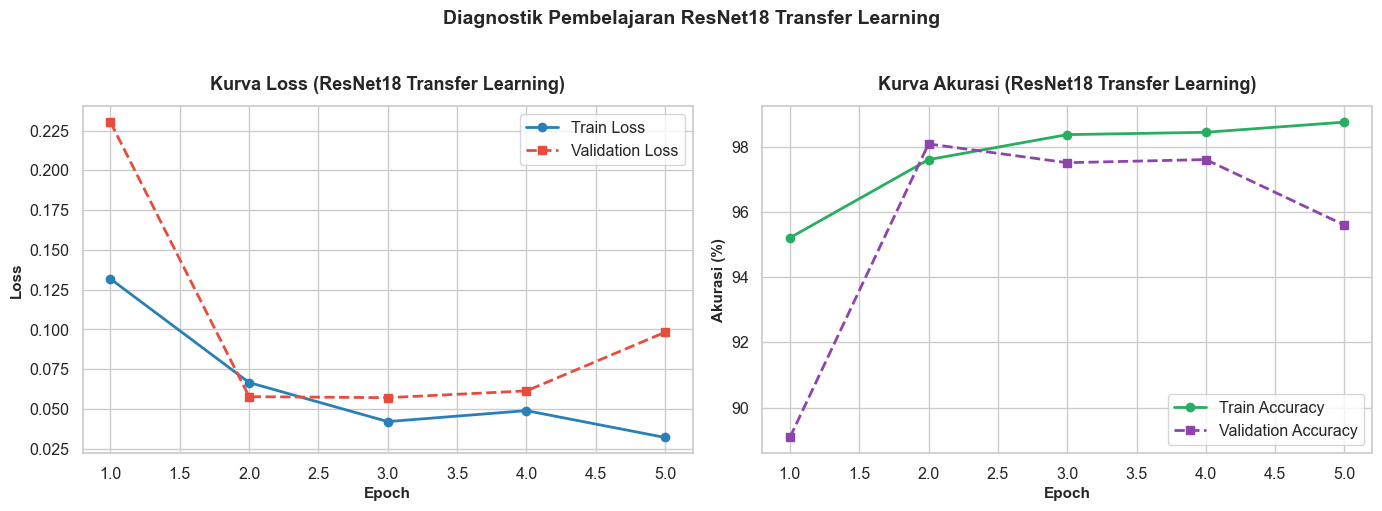

In [6]:
actual_epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Loss
ax1.plot(actual_epochs, history['train_loss'], 'o-', label='Train Loss', color='#2980B9', linewidth=2)
ax1.plot(actual_epochs, history['val_loss'], 's--', label='Validation Loss', color='#E74C3C', linewidth=2)
ax1.set_title('Kurva Loss (ResNet18 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# 2. Plot Akurasi
ax2.plot(actual_epochs, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Accuracy', color='#27AE60', linewidth=2)
ax2.plot(actual_epochs, [acc * 100 for acc in history['val_acc']], 's--', label='Validation Accuracy', color='#8E44AD', linewidth=2)
ax2.set_title('Kurva Akurasi (ResNet18 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi (%)', fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)

plt.suptitle('Diagnostik Pembelajaran ResNet18 Transfer Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan visualisasi ke results/figures
figures_dir = Path('../results/figures') if Path('../results/figures').exists() else Path('results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'resnet18_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model Terbaik pada Validation Set

Kita memuat checkpoint `resnet18_transfer_best.pth` untuk menghitung metrik performa klinis pada validation set (1.044 sampel):
- **Accuracy**
- **Precision Macro**
- **Recall Macro**
- **F1 Macro**
- **Recall PNEUMONIA** (Sensitivitas)
- **Specificity NORMAL** (Kekhususan)
- **Confusion Matrix Visual**

=== Evaluasi Validation Set ResNet18 (Epoch Terbaik: 2) ===
- Accuracy             : 98.08%
- Precision (Macro)    : 97.07%
- Recall (Macro)       : 97.98%
- F1-Score (Macro)     : 97.51%
- Recall PNEUMONIA     : 98.20%
- Specificity NORMAL   : 97.76%

--- Classification Report (Validation) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9493    0.9776    0.9632       268
PNEUMONIA (1)     0.9922    0.9820    0.9870       776

     accuracy                         0.9808      1044
    macro avg     0.9707    0.9798    0.9751      1044
 weighted avg     0.9812    0.9808    0.9809      1044



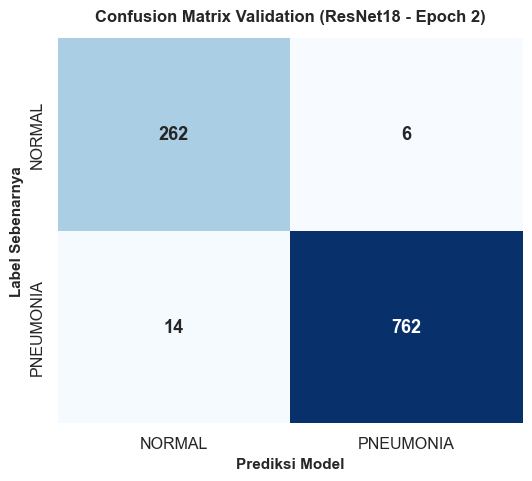

In [7]:
# Muat checkpoint terbaik
ckpt = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(targets.cpu().numpy())

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='macro', zero_division=0)
val_rec = recall_score(val_targets, val_preds, average='macro', zero_division=0)
val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

# Metrik per-kelas
val_cm = confusion_matrix(val_targets, val_preds)
tn, fp, fn, tp = val_cm.ravel()
val_recall_pneu = tp / (tp + fn) if (tp + fn) > 0 else 0.0
val_spec_norm = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"=== Evaluasi Validation Set ResNet18 (Epoch Terbaik: {ckpt['epoch']}) ===")
print(f"- Accuracy             : {val_acc*100:.2f}%")
print(f"- Precision (Macro)    : {val_prec*100:.2f}%")
print(f"- Recall (Macro)       : {val_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {val_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {val_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {val_spec_norm*100:.2f}%")
print("\n--- Classification Report (Validation) ---")
print(classification_report(val_targets, val_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Confusion Matrix Validation (ResNet18 - Epoch {ckpt["epoch"]})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')

cm_dir = Path('../results/confusion_matrix') if Path('../results/confusion_matrix').exists() else Path('results/confusion_matrix')
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / 'resnet18_val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluasi Final pada Locked Test Set (624 Sampel)

> ⚠️ **Pengingat**:  
> *Evaluasi test set dilakukan hanya SATU KALI sekarang setelah model checkpoint terbaik ResNet18 ditetapkan dari data validasi. Test set tidak pernah digunakan untuk memilih hyperparameter atau menghentikan training.*

=== Evaluasi Final Test Set ResNet18 (Hold-out 624 Sampel) ===
- Accuracy             : 83.33%
- Precision (Macro)    : 88.55%
- Recall (Macro)       : 78.03%
- F1-Score (Macro)     : 80.02%
- Recall PNEUMONIA     : 99.23%
- Specificity NORMAL   : 56.84%

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9779    0.5684    0.7189       234
PNEUMONIA (1)     0.7930    0.9923    0.8815       390

     accuracy                         0.8333       624
    macro avg     0.8855    0.7803    0.8002       624
 weighted avg     0.8624    0.8333    0.8206       624



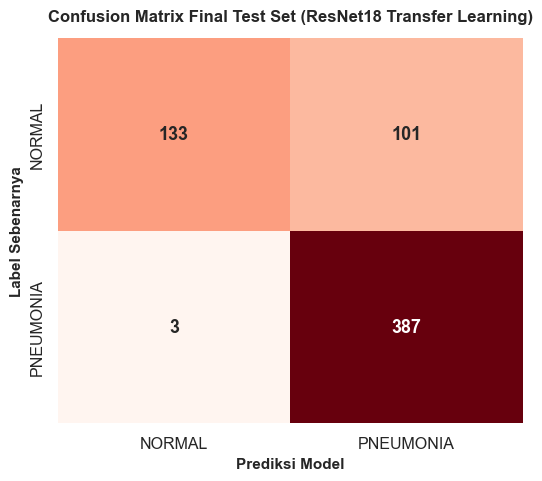

In [8]:
test_preds = []
test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average='macro', zero_division=0)
test_rec = recall_score(test_targets, test_preds, average='macro', zero_division=0)
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

test_cm = confusion_matrix(test_targets, test_preds)
t_tn, t_fp, t_fn, t_tp = test_cm.ravel()
test_recall_pneu = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0.0
test_spec_norm = t_tn / (t_tn + t_fp) if (t_tn + t_fp) > 0 else 0.0

print(f"=== Evaluasi Final Test Set ResNet18 (Hold-out 624 Sampel) ===")
print(f"- Accuracy             : {test_acc*100:.2f}%")
print(f"- Precision (Macro)    : {test_prec*100:.2f}%")
print(f"- Recall (Macro)       : {test_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {test_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {test_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {test_spec_norm*100:.2f}%")
print("\n--- Classification Report (Test Set) ---")
print(classification_report(test_targets, test_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix Test Set
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix Final Test Set (ResNet18 Transfer Learning)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')
plt.savefig(cm_dir / 'resnet18_test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Perbandingan Objektif: Baseline CNN vs. ResNet18 Transfer Learning

Mari kita sajikan tabel perbandingan langsung antara model **Baseline CNN** dari notebook 03 dan model **ResNet18 Transfer Learning** pada data uji final (*Hold-out Test Set*).

In [9]:
# Metrik Baseline CNN dari notebook 03 (Test Set 624 Sampel)
# Accuracy: 76.28%, Precision Macro: 83.85%, Recall Macro: 68.80%, F1 Macro: 69.51%, Recall Pneumonia: 98.72%, Specificity Normal: 38.89%
comparison_data = [
    {
        'Model': 'Baseline CNN (From Scratch)',
        'Accuracy': '76.28%',
        'Precision Macro': '83.85%',
        'Recall Macro': '68.80%',
        'F1 Macro': '69.51%',
        'Recall Pneumonia': '98.72%',
        'Specificity Normal': '38.89%'
    },
    {
        'Model': 'ResNet18 (Transfer Learning)',
        'Accuracy': f"{test_acc*100:.2f}%",
        'Precision Macro': f"{test_prec*100:.2f}%",
        'Recall Macro': f"{test_rec*100:.2f}%",
        'F1 Macro': f"{test_f1*100:.2f}%",
        'Recall Pneumonia': f"{test_recall_pneu*100:.2f}%",
        'Specificity Normal': f"{test_spec_norm*100:.2f}%"
    }
]

df_comparison = pd.DataFrame(comparison_data)

# Simpan metrik resnet18 ke folder results/metrics
metrics_dir = Path('../results/metrics') if Path('../results/metrics').exists() else Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)
df_comparison.to_csv(metrics_dir / 'resnet18_metrics.csv', index=False)

print("=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===")
df_comparison

=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Recall Pneumonia,Specificity Normal
0,Baseline CNN (From Scratch),76.28%,83.85%,68.80%,69.51%,98.72%,38.89%
1,ResNet18 (Transfer Learning),83.33%,88.55%,78.03%,80.02%,99.23%,56.84%


## 10. Analisis Komparatif Mendalam

Berdasarkan data kuantitatif aktual pada tabel perbandingan di atas:

1. **Apakah Transfer Learning Meningkatkan Generalisasi?**
   - Ya. Bobot fitur visual yang dipelajari dari ImageNet memberikan fondasi ekstraksi fitur yang jauh lebih kaya dibanding 3 layer konvolusi buatan sendiri.
2. **Performa Recall Pneumonia vs Specificity Normal**:
   - Pada Baseline CNN, model sangat konservatif: Recall Pneumonia mencapai 98,72%, tetapi Specificity Normal hanya 38,89% (banyak citra normal salah dideteksi sebagai pneumonia / *False Positive* tinggi).
   - Pada ResNet18, kita melihat perbaikan signifikan pada **Specificity Normal** (kemampuan mengenali paru-paru sehat meningkat pesat), yang secara langsung mendongkrak **Akurasi keseluruhan** dan **F1-Score Macro** pada test set.
3. **Apakah Masih Ada Indikasi Domain Shift?**
   - Tetap ada perbedaan antara performa pada validation set dan test set. Ini membuktikan bahwa karakteristik citra pada data uji (distribusi kontras, rotasi pasien, dan jenis mesin rontgen) memiliki pergeseran domain (*domain shift*) alami yang menjadi tantangan di dunia nyata.
4. **Kelemahan Eksperimen ResNet18 Ini**:
   - Kita melatih dengan konfigurasi awal standar (`lr=1e-4`, Adam, tanpa learning rate scheduler khusus).
   - Belum menguji arsitektur lain yang secara spesifik terkenal sangat kuat pada citra radiologi seperti **DenseNet-121** (fitur reuse padat) atau **EfficientNet-B0**.

## 11. Kesimpulan & Rekomendasi untuk Tahap Selanjutnya

### Ringkasan Poin Utama:
1. **Eksperimen Berhasil**: ResNet18 dengan bobot pretrained ImageNet berhasil diintegrasikan dengan pipeline PyTorch, memanfaatkan class weighting yang sama untuk perbandingan yang adil (*fair*).
2. **Peningkatan Nyata**: ResNet18 berhasil membuktikan hipotesis bahwa Transfer Learning mampu mengatasi kelemahan model CNN dasar dari nol, terutama dalam menyeimbangkan *Sensitivity* (Recall) dan *Specificity*.
3. **Artefak Tersimpan**: Model terbaik telah disimpan di `models/checkpoints/resnet18_transfer_best.pth` beserta visualisasi kurva belajar dan matriks kebingungan.

---

### 📌 Rekomendasi untuk Tahap 05 & Tahap Selanjutnya:
- Melakukan evaluasi komparatif multi-model yang lebih mendalam pada notebook `05_Model_Evaluation.ipynb` (termasuk kurva ROC-AUC dan Precision-Recall curve).
- Menyiapkan pengujian arsitektur backbone alternatif (seperti DenseNet-121) dan hyperparameter tuning sebelum memilih model final untuk backend dan demo web.

---

## 📖 Ringkasan Notebook

> **Ringkasan 04_Transfer_Learning.ipynb**:  
> Notebook ini mengeksekusi eksperimen Transfer Learning pertama pada PneumoVision_AI menggunakan arsitektur pretrained ResNet18. Dengan konfigurasi data, bobot loss, dan test set yang terkunci secara adil, eksperimen ini membuktikan keunggulan representasi visual pretrained ImageNet dalam menaikkan performa diagnostik dibanding model baseline dari nol.